In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS
import numpy as np

try:
    import scienceplots  # noqa
    plt.style.use(['science', 'no-latex'])
    plt.rcParams['axes.unicode_minus'] = False
except ImportError:
    pass

In [6]:
# Generate synthetic data from a truncated normal
rng = np.random.default_rng(42)

mu_true = 1.2
sigma_true = 0.4
low = 0.5
N = 500

# Rejection sampling
samples = []
while len(samples) < N:
    x = rng.normal(mu_true, sigma_true)
    if x > low:
        samples.append(x)
data = jnp.array(samples)

print(f"N = {len(data)}, min = {data.min():.3f}, max = {data.max():.3f}")
print(f"True: mu = {mu_true}, sigma = {sigma_true}, low = {low}")

N = 500, min = 0.502, max = 2.366
True: mu = 1.2, sigma = 0.4, low = 0.5


In [7]:
def model(obs):
    mu = numpyro.sample("mu", dist.Normal(0.0, 5.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(2.0))

    with numpyro.plate("data", len(obs)):
        numpyro.sample(
            "x",
            dist.TruncatedDistribution(dist.Normal(mu, sigma), low=low),
            obs=obs,
        )

In [8]:
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=2000, num_chains=2,
            chain_method="sequential")
mcmc.run(jax.random.key(0), data)
mcmc.print_summary()

sample: 100%|██████████| 2500/2500 [00:00<00:00, 7287.37it/s, 3 steps of size 8.83e-01. acc. prob=0.91]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      1.19      0.02      1.19      1.15      1.22   2434.58      1.00
     sigma      0.40      0.02      0.39      0.37      0.42   2222.93      1.00

Number of divergences: 0


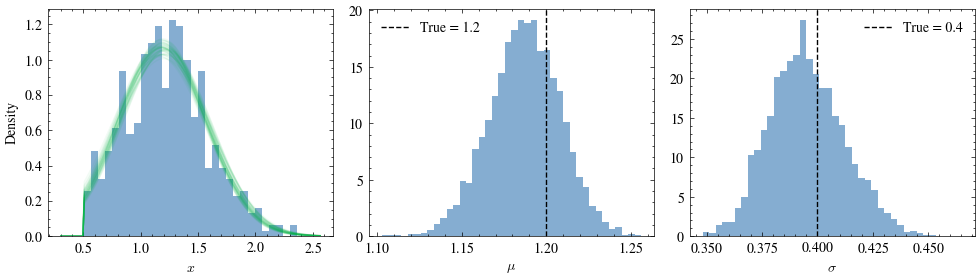

In [9]:
posterior = mcmc.get_samples()
mu_post = np.asarray(posterior["mu"])
sigma_post = np.asarray(posterior["sigma"])

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# Data histogram + posterior predictive
ax = axes[0]
xgrid = np.linspace(data.min() - 0.2, data.max() + 0.2, 200)
ax.hist(np.asarray(data), bins=30, density=True, alpha=0.5, label="Data")

# Plot a few posterior draws
for i in rng.choice(len(mu_post), 50, replace=False):
    from scipy.stats import truncnorm
    a = (low - mu_post[i]) / sigma_post[i]
    pdf = truncnorm.pdf(xgrid, a, np.inf, loc=mu_post[i], scale=sigma_post[i])
    ax.plot(xgrid, pdf, color="C1", alpha=0.05)

ax.set_xlabel(r"$x$")
ax.set_ylabel("Density")

# mu posterior
ax = axes[1]
ax.hist(mu_post, bins=40, density=True, alpha=0.5)
ax.axvline(mu_true, color="k", ls="--", label=f"True = {mu_true}")
ax.set_xlabel(r"$\mu$")
ax.legend()

# sigma posterior
ax = axes[2]
ax.hist(sigma_post, bins=40, density=True, alpha=0.5)
ax.axvline(sigma_true, color="k", ls="--", label=f"True = {sigma_true}")
ax.set_xlabel(r"$\sigma$")
ax.legend()

fig.tight_layout()
plt.show()


## Fit logP for C22 and C27

C22 has a period selection cut at `logP_min = 0.903`, so we fit a truncated normal (`logP > 0.903`). C27 has no period selection, so we fit a plain normal.

In [13]:
import sys
sys.path.insert(0, "..")
from candel import load_config
from candel.pvdata import CepheidData, to_mwcepheids_config

config = to_mwcepheids_config(load_config("../scripts/config.toml", replace_los_prior=False))
cepheid_data = CepheidData(config)
split = cepheid_data.split_by_campaign()

logP_C22 = np.asarray(split["C22"].logP) if "C22" in split else None
logP_C27 = np.asarray(split["C27"].logP) if "C27" in split else None

if logP_C22 is not None:
    print(f"C22: N={len(logP_C22)}, logP range [{logP_C22.min():.3f}, {logP_C22.max():.3f}]")
if logP_C27 is not None:
    print(f"C27: N={len(logP_C27)}, logP range [{logP_C27.min():.3f}, {logP_C27.max():.3f}]")

2026-02-16 03:24:18 ============================================================
2026-02-16 03:24:18 Model Configuration
2026-02-16 03:24:18 ============================================================
2026-02-16 03:24:18   Model type      : forward
2026-02-16 03:24:18   Distance prior  : disk
2026-02-16 03:24:18   Scatter         : per-campaign
2026-02-16 03:24:18   Spiral arms     : disabled
2026-02-16 03:24:18 ------------------------------------------------------------
2026-02-16 03:24:18 C22 Selection
2026-02-16 03:24:18 ------------------------------------------------------------
2026-02-16 03:24:18   mW selection    : ENABLED
2026-02-16 03:24:18   mW_max          : 8.000
2026-02-16 03:24:18   mW_width        : 0.500
2026-02-16 03:24:18   AH selection    : disabled
2026-02-16 03:24:18   pi selection    : ENABLED
2026-02-16 03:24:18   pi_min          : 0.300
2026-02-16 03:24:18   pi_smooth       : True
2026-02-16 03:24:18   pi_width        : 0.1
2026-02-16 03:24:18   Distance grid

In [14]:
# C22: truncated normal (logP > 0.903)
C22_LOGP_MIN = 0.903

def model_c22(obs):
    mu = numpyro.sample("mu", dist.Normal(1.0, 1.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    with numpyro.plate("data", len(obs)):
        numpyro.sample(
            "x",
            dist.TruncatedDistribution(
                dist.Normal(mu, sigma), low=C22_LOGP_MIN),
            obs=obs,
        )

kernel = NUTS(model_c22)
mcmc_c22 = MCMC(kernel, num_warmup=500, num_samples=2000, num_chains=2,
                chain_method="sequential")
mcmc_c22.run(jax.random.key(1), jnp.array(logP_C22))
mcmc_c22.print_summary()

sample: 100%|██████████| 2500/2500 [00:00<00:00, 9573.19it/s, 15 steps of size 2.40e-01. acc. prob=0.87]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      0.58      0.47      0.72     -0.06      1.19    606.59      1.00
     sigma      0.46      0.14      0.44      0.25      0.68    586.94      1.00

Number of divergences: 17


In [15]:
# C27: plain normal (no period selection)
def model_c27(obs):
    mu = numpyro.sample("mu", dist.Normal(1.0, 1.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    with numpyro.plate("data", len(obs)):
        numpyro.sample("x", dist.Normal(mu, sigma), obs=obs)

kernel = NUTS(model_c27)
mcmc_c27 = MCMC(kernel, num_warmup=500, num_samples=2000, num_chains=2,
                chain_method="sequential")
mcmc_c27.run(jax.random.key(2), jnp.array(logP_C27))
mcmc_c27.print_summary()

sample: 100%|██████████| 2500/2500 [00:00<00:00, 10799.28it/s, 3 steps of size 8.08e-01. acc. prob=0.92]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      0.76      0.03      0.76      0.71      0.81   2171.41      1.00
     sigma      0.15      0.03      0.15      0.11      0.19   2083.53      1.00

Number of divergences: 0


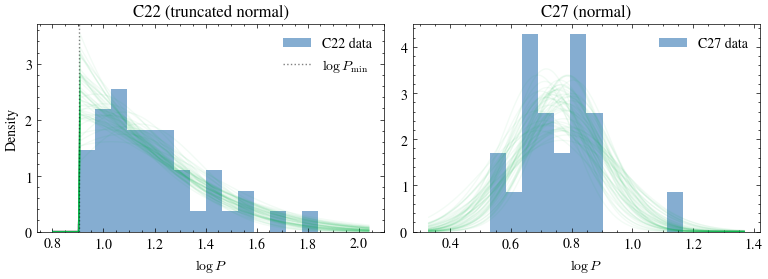

C22: mu = 0.584 +/- 0.473, sigma = 0.464 +/- 0.144
C27: mu = 0.758 +/- 0.032, sigma = 0.149 +/- 0.026


In [16]:
from scipy.stats import truncnorm, norm

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# --- C22 ---
ax = axes[0]
post_c22 = mcmc_c22.get_samples()
mu_c22 = np.asarray(post_c22["mu"])
sig_c22 = np.asarray(post_c22["sigma"])

xgrid = np.linspace(C22_LOGP_MIN - 0.1, logP_C22.max() + 0.2, 200)
ax.hist(logP_C22, bins=15, density=True, alpha=0.5, label="C22 data")

for i in np.random.choice(len(mu_c22), 50, replace=False):
    a = (C22_LOGP_MIN - mu_c22[i]) / sig_c22[i]
    pdf = truncnorm.pdf(xgrid, a, np.inf, loc=mu_c22[i], scale=sig_c22[i])
    ax.plot(xgrid, pdf, color="C1", alpha=0.05)

ax.axvline(C22_LOGP_MIN, color="k", ls=":", alpha=0.5, label=r"$\log P_{\min}$")
ax.set_xlabel(r"$\log P$")
ax.set_ylabel("Density")
ax.set_title("C22 (truncated normal)")
ax.legend()

# --- C27 ---
ax = axes[1]
post_c27 = mcmc_c27.get_samples()
mu_c27 = np.asarray(post_c27["mu"])
sig_c27 = np.asarray(post_c27["sigma"])

xgrid = np.linspace(logP_C27.min() - 0.2, logP_C27.max() + 0.2, 200)
ax.hist(logP_C27, bins=12, density=True, alpha=0.5, label="C27 data")

for i in np.random.choice(len(mu_c27), 50, replace=False):
    pdf = norm.pdf(xgrid, loc=mu_c27[i], scale=sig_c27[i])
    ax.plot(xgrid, pdf, color="C1", alpha=0.05)

ax.set_xlabel(r"$\log P$")
ax.set_title("C27 (normal)")
ax.legend()

fig.tight_layout()
plt.show()

print(f"C22: mu = {mu_c22.mean():.3f} +/- {mu_c22.std():.3f}, "
      f"sigma = {sig_c22.mean():.3f} +/- {sig_c22.std():.3f}")
print(f"C27: mu = {mu_c27.mean():.3f} +/- {mu_c27.std():.3f}, "
      f"sigma = {sig_c27.mean():.3f} +/- {sig_c27.std():.3f}")